<a href="https://colab.research.google.com/github/MikeMitch04/A03-knn/blob/main/A03_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Michael Mitchell & Carter Shaffer

**Date:** 10/1/2026

**Question 1 Solutions**

**Q1.1 -** Regression is for predicting a number, like a car's price or sales. Classification is for predicting a category, like a vehicle's class or a mine's type. With kNN, the only difference is how the neighbors get combined: for regression you average their values, and for classification you go with whichever class shows up most among them.

**Q1.2 -** A confusion table compares what the model predicted to what the actual class was. Rows are the true classes and columns are the predictions, so everything on the diagonal is a correct call and everything off it is a mistake. It's more useful than accuracy alone because it tells you which classes the model mixes up. That matters a lot when some mistakes are worse than others.

**Q1.3 -** SSE adds up the squared differences between the actual and predicted values. It's basically a measure of how far off a regression model's predictions are overall. Since the errors are squared, one big miss counts a lot more than a few small ones. A lower SSE on data the model hasn't seen means it's predicting better.

**Q1.4 -** Overfitting is when a model memorizes the training data, noise included, so it looks great on that data but falls apart on new data. In kNN this happens when k is really small. Underfitting is the opposite: the model is too simple to pick up the real patterns, so it does poorly everywhere. That's what you get with a really large k, where every prediction ends up looking about the same.

**Q1.5 -** If you picked k based on training error, you'd always end up with k = 1, because every training point is its own closest neighbor. Checking performance on data the model didn't train on shows how it will actually do on new cases, so you end up with a k that isn't overfitting or underfitting. One catch is that once you use the test set to choose k, it's no longer a totally fair test, and the score will be a bit optimistic. Ideally you'd save a separate test set for the very end.

**Q1.6 -** Giving a single class label is simple, but it hides how confident the model is. A prediction the neighbors split 51/49 on looks exactly the same as one they all agree on. Giving probabilities (the share of the k neighbors in each class) shows that uncertainty and lets whoever uses the model decide how sure they need to be, depending on how costly a mistake would be. The downside is that probabilities are harder to explain to people, and with kNN they're pretty rough, since they can only be multiples of 1/k and they change depending on which k you pick.

338 rows, 4 columns

Missing values per column:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

Feature summary:
       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000 

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 

Soil value counts:
soil
0.0    59
0.2    51
0.4    56
0.6    57
0.8    58
1.0    57
Name: count, dtype: int64 

Feature means by mine type:
           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


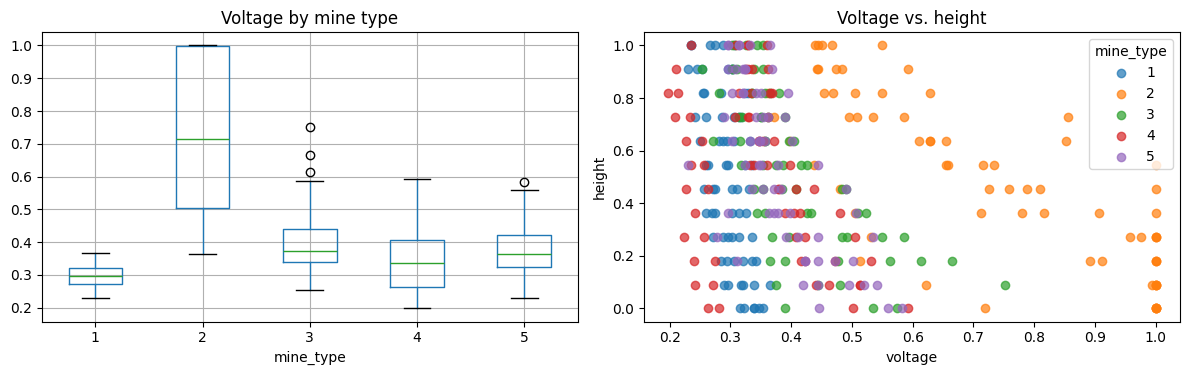

In [12]:
# Question 2.1 Solution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Load the data
df = pd.read_csv("land_mines.csv")
print(f"{df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values per column:")
print(df.isna().sum(), "\n")

# Summary of the features
print("Feature summary:")
print(df[["voltage", "height", "soil"]].describe().round(3), "\n")

# Summary of the target
print("Mine type counts:")
print(df["mine_type"].value_counts().sort_index(), "\n")

# Soil only takes a handful of values, so count them
print("Soil value counts:")
print(df["soil"].value_counts().sort_index(), "\n")

# Average feature values for each mine type
print("Feature means by mine type:")
print(df.groupby("mine_type")[["voltage", "height", "soil"]].mean().round(3))

# Plots: voltage by mine type, and voltage vs. height colored by type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column="voltage", by="mine_type", ax=axes[0])
axes[0].set_title("Voltage by mine type")
axes[0].set_xlabel("mine_type")
for t, g in df.groupby("mine_type"):
    axes[1].scatter(g["voltage"], g["height"], label=str(t), alpha=0.7)
axes[1].set_xlabel("voltage")
axes[1].set_ylabel("height")
axes[1].set_title("Voltage vs. height")
axes[1].legend(title="mine_type")
plt.suptitle("")
plt.tight_layout()
plt.show()

The dataset has 338 mines, no missing values, and three features. The five mine types are evenly split (65 to 71 each), so accuracy should be a fair way to judge the model. Voltage and height are already scaled 0 to 1, and soil only takes six values, so it works more like a category than a continuous measurement. Type 2 mines stand out with much higher voltage than the rest, so they should be easy to classify. Types 1, 3, 4, and 5 overlap a lot on voltage and height, so that's where I'd expect most of the model's mistakes. Soil looks spread evenly across all the types, so it probably won't help much in telling them apart.

In [13]:
# Question 2.2 Solution

# Features and target
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

# 50/50 split, stratified so each mine type is split evenly between the two halves
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100, stratify=y
)

# Fit the scaler on the training data only, then apply it to the test data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Check the split sizes and class balance
print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows\n")
split_counts = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
print("Mine type counts in each set:")
print(split_counts)

Training set: 169 rows
Test set: 169 rows

Mine type counts in each set:
           train  test
mine_type             
1             35    36
2             35    35
3             33    33
4             33    33
5             33    32


I split the data 50/50, giving 169 mines in each set. Using `stratify=y` keeps every mine type divided evenly between the two halves, so no class ends up mostly in one set, which is easy to do with a dataset this small. I split before scaling, so the scaler learns the min and max from the training data only and applies them to the test data. That keeps any information from the test set out of the model.

Best k = 3
Test accuracy at k = 3: 0.467


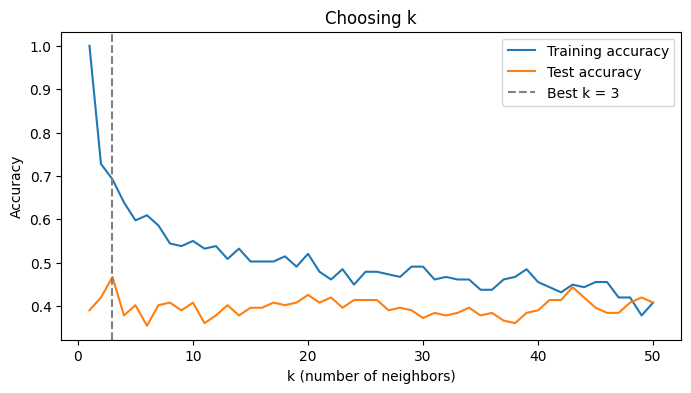

In [14]:
# Question 2.3 Solution

# Try every k from 1 to 50 and record accuracy on the training and test sets
ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

# Pick the k with the highest test accuracy
k_star = int(ks[np.argmax(test_acc)])
print(f"Best k = {k_star}")
print(f"Test accuracy at k = {k_star}: {max(test_acc):.3f}")

# Plot training vs. test accuracy across k
plt.figure(figsize=(8, 4))
plt.plot(ks, train_acc, label="Training accuracy")
plt.plot(ks, test_acc, label="Test accuracy")
plt.axvline(k_star, linestyle="--", color="gray", label=f"Best k = {k_star}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Choosing k")
plt.legend()
plt.show()

# Fit the final model with the best k
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)

I fit a kNN classifier for every k from 1 to 50 and checked its accuracy on the test set. I chose k = 3 because it had the highest test accuracy, at 46.7%. That beats the 20% you'd get by guessing randomly among five types, but the model still gets more than half the test mines wrong. Training accuracy is 100% at k = 1, since every point is its own nearest neighbor, so choosing k that way would overfit. After k = 3, test accuracy mostly flattens out between 36% and 44%, and by k = 50 the training and test lines meet, a sign of underfitting. The peak at k = 3 is small relative to the noise, so a different split could pick a different k.

In [15]:
# Question 2.4 Solution

# Predict on the test set with the best model
y_hat = best_model.predict(X_test)

# Confusion table: rows are actual mine types, columns are predicted
labels = sorted(y.unique())
cm = pd.DataFrame(
    confusion_matrix(y_test, y_hat, labels=labels),
    index=[f"Actual {c}" for c in labels],
    columns=[f"Pred {c}" for c in labels],
)
print("Confusion table:")
print(cm, "\n")

# Overall accuracy
print(f"Overall accuracy: {accuracy_score(y_test, y_hat):.3f}\n")

# Accuracy within each actual mine type
per_class = pd.Series(
    np.diag(cm) / cm.sum(axis=1).to_numpy(),
    index=[f"Type {c}" for c in labels],
)
print("Accuracy by mine type:")
print(per_class.round(3))

Confusion table:
          Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
Actual 1      26       0       4       2       4
Actual 2       0      30       2       2       1
Actual 3      12       3      10       1       7
Actual 4       9       4      10       8       2
Actual 5      10       1      14       2       5 

Overall accuracy: 0.467

Accuracy by mine type:
Type 1    0.722
Type 2    0.857
Type 3    0.303
Type 4    0.242
Type 5    0.156
dtype: float64


The model with k = 3 gets 46.7% of the test mines right. Type 2 is classified the best, at 85.7%, which makes sense given how much higher its voltage is than every other type's. Type 1 also does fairly well, at 72.2%. Performance falls apart for types 3, 4, and 5, at 30.3%, 24.2%, and 15.6%. These types overlap heavily in voltage and height, and the model mixes them up constantly. For example, 14 actual type 5 mines were predicted as type 3, almost three times as many as were classified correctly. The model also over-predicts type 1: 31 real mines from types 3, 4, and 5 were labeled as type 1, which is a big concern if type 1 means no mine.

In [16]:
# Question 2.5 Solution

# Predicted probabilities for each mine type on the test set
proba = pd.DataFrame(
    best_model.predict_proba(X_test),
    columns=[f"P(type {c})" for c in best_model.classes_],
).round(2)
proba["actual"] = y_test.to_numpy()
proba["predicted"] = y_hat
print("Predicted probabilities for the first 10 test mines:")
print(proba.head(10), "\n")

# The most dangerous mistake: calling a real mine "no mine" (type 1)
missed_mines = ((y_test.to_numpy() != 1) & (y_hat == 1)).sum()
false_alarms = ((y_test.to_numpy() == 1) & (y_hat != 1)).sum()
print(f"Real mines predicted as no mine (type 1): {missed_mines}")
print(f"No-mine cases predicted as a mine: {false_alarms}\n")

# How confident is the model? Share of predictions where the top class got under 70% of the vote
top_prob = best_model.predict_proba(X_test).max(axis=1)
print(f"Predictions with less than 70% confidence: {(top_prob < 0.70).mean():.1%}")

Predicted probabilities for the first 10 test mines:
   P(type 1)  P(type 2)  P(type 3)  P(type 4)  P(type 5)  actual  predicted
0       0.00       0.00       0.00       0.67       0.33       5          4
1       0.33       0.00       0.33       0.33       0.00       5          1
2       0.33       0.00       0.33       0.00       0.33       3          1
3       0.33       0.00       0.33       0.00       0.33       5          1
4       0.00       0.33       0.00       0.33       0.33       2          2
5       0.00       1.00       0.00       0.00       0.00       2          2
6       0.33       0.00       0.67       0.00       0.00       4          3
7       0.33       0.00       0.33       0.33       0.00       1          1
8       0.33       0.00       0.33       0.00       0.33       3          1
9       0.00       0.33       0.33       0.33       0.00       4          2 

Real mines predicted as no mine (type 1): 31
No-mine cases predicted as a mine: 10

Predictions with less tha

In this dataset, type 1 means no mine and types 2 through 5 are different mines. The worst mistake is calling a real mine "no mine," since someone could get hurt. On the test set, the model did this 31 times, which is nearly a quarter of the real mines. It also isn't very confident: about 85% of its predictions got less than 70% of the neighbors' votes. I'd use the model as a screening tool, not a final answer. Every detection should be treated as a live mine until an expert confirms it. Users should look at the predicted probabilities rather than just the label, and handle anything the model isn't confident is type 1 as a mine. When the probability is split across types 3, 4, and 5, follow the procedure for the most dangerous of those. Type 2 predictions are the most reliable.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 5fcd805754546f3a9c331c926be0c3c026cd3636
- **AI tool and model used:** ChatGPT-5.6 Sol

### *Prompts used

1. I'm working on a k-nearest neighbors classification lab for my data science class. I've attached my notebook, the dataset, and some of our course materials. Can you look over what I did in Phase 1 and point out anything I should fix or improve? I'm mainly looking for issues with my code, calculations, model setup, choice of k, confusion table, how I interpreted the model's performance, or my written conclusions. Don't redo the whole lab for me, just give me a short numbered list of changes you'd recommend and why.
2. Can you take another look at those suggestions and make sure they actually fit the assignment, the dataset, and the methods covered in our class materials? Double check my EDA, train/test split, scaling, choice of k, accuracy calculations, confusion table, predicted probabilities, and interpretations. If any of your original suggestions were unnecessary or wrong, take them out. Then give me a final numbered list of the changes you still think I should make.

### *AI-proposed changes


1. Clarify the interpretation of kNN predicted probabilities. Explain that they represent the proportion of the nearest neighbors belonging to each class rather than treating them simply as model confidence.
2. Reconsider treating soil as a continuous distance feature. Since soil only takes six discrete values, using ordinary Euclidean distance may make differences between soil categories behave like continuous numerical distances.
3. Use a validation approach to choose \(k\) rather than selecting it on the same test set used for final accuracy. Choosing \(k=3\) based on test accuracy and then reporting that same test accuracy can make the final performance estimate overly optimistic.
4. Add more EDA for height and soil by mine type. The current plots focus mostly on voltage and voltage versus height, even though all three features are used by the kNN model.
5. Report the dangerous Type 1 error as a rate, not just a count. The analysis correctly identifies real mines predicted as Type 1 as the most important error, but reporting the percentage of actual mines missed would make the safety implications easier to interpret.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Describing the predicted probabilities as the proportion of the nearest neighbors belonging to each class is more precise than simply calling them the model’s confidence. |
| 2 | Reject | While soil only has six possible values, the assignment provides it as a numerical feature and uses it in the kNN model. Changing how soil is treated would go beyond the methods we have covered in class. |
| 3 | Reject | While a separate validation set could be useful in practice, the lab has us compare different values of k using the provided train/test setup. Adding another split would go beyond what the assignment is asking us to do. |
| 4 | Accept | Adding some additional EDA for height and soil would give us a more complete understanding of the predictors used in the kNN model instead of focusing mostly on voltage. |
| 5 | Accept | Reporting the Type 1 error as an exact rate in addition to the count would make the interpretation clearer and better show how often the model makes this important mistake. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Question 1 AI-Assisted Solutions

**Q1.1 -** Regression is for predicting a number, like a car's price or sales. Classification is for predicting a category, like a vehicle's class or a mine's type. With kNN, the only difference is how the neighbors get combined: for regression you average their values, and for classification you go with whichever class shows up most among them.

**Q1.2 -** A confusion table compares what the model predicted to what the actual class was. Rows are the true classes and columns are the predictions, so everything on the diagonal is a correct call and everything off it is a mistake. It's more useful than accuracy alone because it tells you which classes the model mixes up. That matters a lot when some mistakes are worse than others.

**Q1.3 -** SSE adds up the squared differences between the actual and predicted values. It's basically a measure of how far off a regression model's predictions are overall. Since the errors are squared, one big miss counts a lot more than a few small ones. A lower SSE on data the model hasn't seen means it's predicting better.

**Q1.4 -** Overfitting is when a model memorizes the training data, noise included, so it looks great on that data but falls apart on new data. In kNN this happens when k is really small. Underfitting is the opposite: the model is too simple to pick up the real patterns, so it does poorly everywhere. That's what you get with a really large k, where every prediction ends up looking about the same.

**Q1.5 -** If you picked k based on training error, you'd always end up with k = 1, because every training point is its own closest neighbor. Checking performance on data the model didn't train on shows how it will actually do on new cases, so you end up with a k that isn't overfitting or underfitting. One catch is that once you use the test set to choose k, it's no longer a totally fair test, and the score will be a bit optimistic. Ideally you'd save a separate test set for the very end.

**Q1.6 -** Giving a single class label is simple, but it hides how much agreement there is among the nearest neighbors. A prediction the neighbors split 51/49 on looks exactly the same as one they all agree on. Giving probabilities (the share of the k neighbors in each class) shows that uncertainty and lets whoever uses the model decide how sure they need to be, depending on how costly a mistake would be. The downside is that probabilities are harder to explain to people, and with kNN they're pretty rough, since they can only be multiples of 1/k and they change depending on which k you pick.

338 rows, 4 columns

Missing values per column:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

Feature summary:
       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000 

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 

Soil value counts:
soil
0.0    59
0.2    51
0.4    56
0.6    57
0.8    58
1.0    57
Name: count, dtype: int64 

Feature means by mine type:
           voltage  height   soil
mine_type                        
1            0.296   0.496  0.493
2            0.721   0.487  0.509
3            0.402   0.528  0.497
4            0.345   0.507  0.503
5            0.380   0.530  0.517


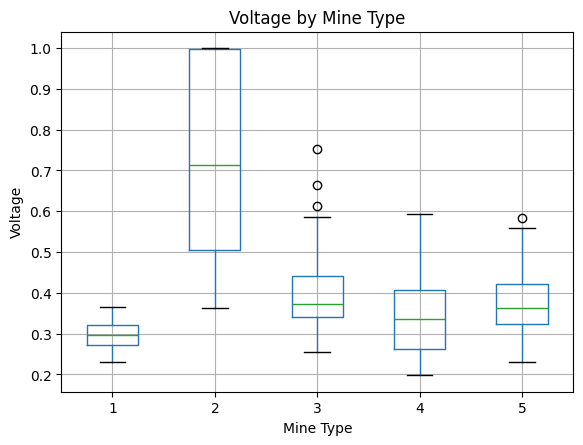

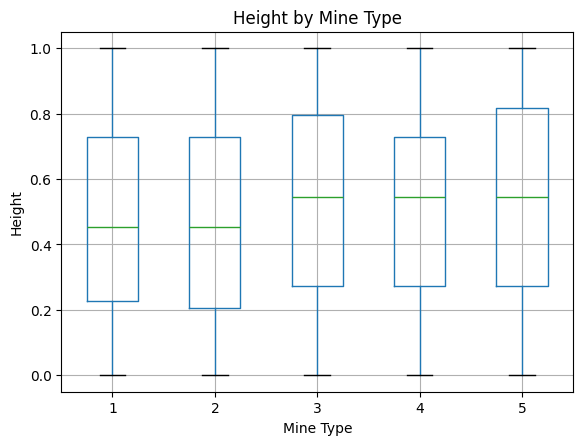

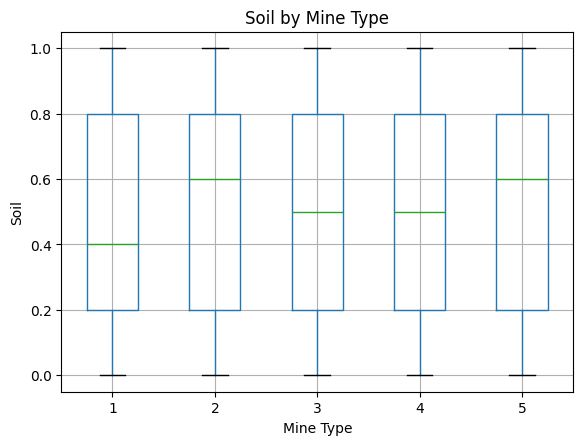

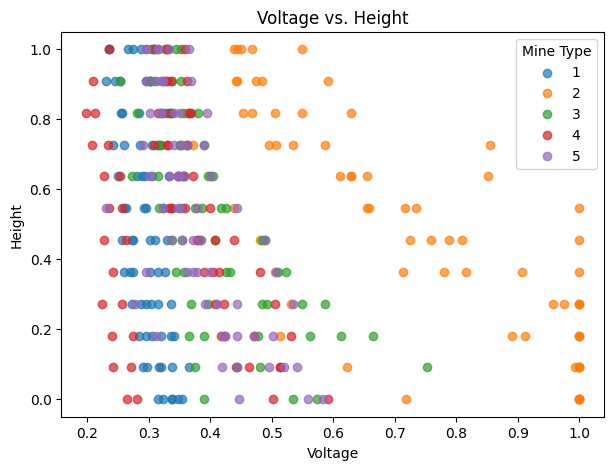

In [17]:
# Question 2.1 AI-Assisted Solution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("land_mines.csv")

print(f"{df.shape[0]} rows, {df.shape[1]} columns\n")

print("Missing values per column:")
print(df.isna().sum(), "\n")

print("Feature summary:")
print(df[["voltage", "height", "soil"]].describe().round(3), "\n")

print("Mine type counts:")
print(df["mine_type"].value_counts().sort_index(), "\n")

print("Soil value counts:")
print(df["soil"].value_counts().sort_index(), "\n")

print("Feature means by mine type:")
print(df.groupby("mine_type")[["voltage", "height", "soil"]].mean().round(3))

# Voltage by mine type
df.boxplot(column="voltage", by="mine_type")
plt.title("Voltage by Mine Type")
plt.suptitle("")
plt.xlabel("Mine Type")
plt.ylabel("Voltage")
plt.show()

# Height by mine type
df.boxplot(column="height", by="mine_type")
plt.title("Height by Mine Type")
plt.suptitle("")
plt.xlabel("Mine Type")
plt.ylabel("Height")
plt.show()

# Soil by mine type
df.boxplot(column="soil", by="mine_type")
plt.title("Soil by Mine Type")
plt.suptitle("")
plt.xlabel("Mine Type")
plt.ylabel("Soil")
plt.show()

# Voltage vs. height colored by mine type
plt.figure(figsize=(7, 5))

for t, g in df.groupby("mine_type"):
    plt.scatter(
        g["voltage"],
        g["height"],
        label=str(t),
        alpha=0.7
    )

plt.xlabel("Voltage")
plt.ylabel("Height")
plt.title("Voltage vs. Height")
plt.legend(title="Mine Type")
plt.show()

The dataset has 338 observations, no missing values, and three features. The five mine types are fairly evenly split, with 65 to 71 observations each. Voltage and height range from 0 to 1, while soil only takes six possible values. Type 2 mines stand out with a much higher average voltage than the other mine types, so they should be easier to classify. The additional EDA shows that height and soil are very similar across all five mine types, so they do not appear to separate the classes very well on their own. Types 1, 3, 4, and 5 overlap considerably across the features, so I would expect most of the model's mistakes to occur between those groups.

In [18]:
# Question 2.2 Solution

# Features and target
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

# 50/50 split, stratified so each mine type is split evenly between the two halves
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100, stratify=y
)

# Fit the scaler on the training data only, then apply it to the test data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Check the split sizes and class balance
print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows\n")
split_counts = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
print("Mine type counts in each set:")
print(split_counts)

Training set: 169 rows
Test set: 169 rows

Mine type counts in each set:
           train  test
mine_type             
1             35    36
2             35    35
3             33    33
4             33    33
5             33    32


I split the data 50/50, giving 169 mines in each set. Using `stratify=y` keeps every mine type divided evenly between the two halves, so no class ends up mostly in one set, which is easy to do with a dataset this small. I split before scaling, so the scaler learns the min and max from the training data only and applies them to the test data. That keeps any information from the test set out of the model.

Best k = 3
Test accuracy at k = 3: 0.467


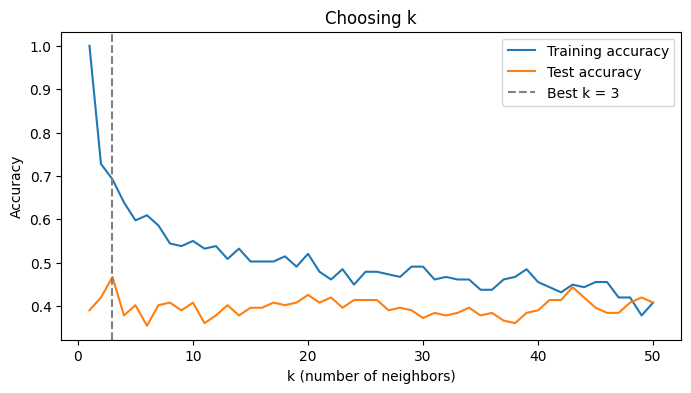

In [19]:
# Question 2.3 Solution

# Try every k from 1 to 50 and record accuracy on the training and test sets
ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

# Pick the k with the highest test accuracy
k_star = int(ks[np.argmax(test_acc)])
print(f"Best k = {k_star}")
print(f"Test accuracy at k = {k_star}: {max(test_acc):.3f}")

# Plot training vs. test accuracy across k
plt.figure(figsize=(8, 4))
plt.plot(ks, train_acc, label="Training accuracy")
plt.plot(ks, test_acc, label="Test accuracy")
plt.axvline(k_star, linestyle="--", color="gray", label=f"Best k = {k_star}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Choosing k")
plt.legend()
plt.show()

# Fit the final model with the best k
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)

I fit a kNN classifier for every k from 1 to 50 and checked its accuracy on the test set. I chose k = 3 because it had the highest test accuracy, at 46.7%. That beats the 20% you'd get by guessing randomly among five types, but the model still gets more than half the test mines wrong. Training accuracy is 100% at k = 1, since every point is its own nearest neighbor, so choosing k that way would overfit. After k = 3, test accuracy mostly flattens out between 36% and 44%, and by k = 50 the training and test lines meet, a sign of underfitting. The peak at k = 3 is small relative to the noise, so a different split could pick a different k.

In [20]:
# Question 2.4 Solution

# Predict on the test set with the best model
y_hat = best_model.predict(X_test)

# Confusion table: rows are actual mine types, columns are predicted
labels = sorted(y.unique())
cm = pd.DataFrame(
    confusion_matrix(y_test, y_hat, labels=labels),
    index=[f"Actual {c}" for c in labels],
    columns=[f"Pred {c}" for c in labels],
)
print("Confusion table:")
print(cm, "\n")

# Overall accuracy
print(f"Overall accuracy: {accuracy_score(y_test, y_hat):.3f}\n")

# Accuracy within each actual mine type
per_class = pd.Series(
    np.diag(cm) / cm.sum(axis=1).to_numpy(),
    index=[f"Type {c}" for c in labels],
)
print("Accuracy by mine type:")
print(per_class.round(3))

Confusion table:
          Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
Actual 1      26       0       4       2       4
Actual 2       0      30       2       2       1
Actual 3      12       3      10       1       7
Actual 4       9       4      10       8       2
Actual 5      10       1      14       2       5 

Overall accuracy: 0.467

Accuracy by mine type:
Type 1    0.722
Type 2    0.857
Type 3    0.303
Type 4    0.242
Type 5    0.156
dtype: float64


The model with k = 3 gets 46.7% of the test mines right. Type 2 is classified the best, at 85.7%, which makes sense given how much higher its voltage is than every other type's. Type 1 also does fairly well, at 72.2%. Performance falls apart for types 3, 4, and 5, at 30.3%, 24.2%, and 15.6%. These types overlap heavily in voltage and height, and the model mixes them up constantly. For example, 14 actual type 5 mines were predicted as type 3, almost three times as many as were classified correctly. The model also over-predicts type 1: 31 real mines from types 3, 4, and 5 were labeled as type 1, which is a big concern if type 1 means no mine.

In [21]:
# Question 2.5 AI-Assisted Solution

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

# Load the data
df = pd.read_csv("land_mines.csv")
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

# Same split and scaling as Phase 1
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100, stratify=y
)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Same model as Phase 1 (k = 3)
best_model = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
y_hat = best_model.predict(X_test)

# Predicted probabilities (share of the 3 nearest neighbors in each class)
proba = pd.DataFrame(
    best_model.predict_proba(X_test),
    columns=[f"P(type {c})" for c in best_model.classes_],
).round(2)
proba["actual"] = y_test.to_numpy()
proba["predicted"] = y_hat
print("Predicted probabilities for the first 10 test mines:")
print(proba.head(10), "\n")

# Real mines predicted as no mine (type 1), as a count and a rate
actual = y_test.to_numpy()
missed_mines = ((actual != 1) & (y_hat == 1)).sum()
actual_mines = (actual != 1).sum()
false_alarms = ((actual == 1) & (y_hat != 1)).sum()
print(f"Real mines predicted as no mine (type 1): {missed_mines}")
print(f"Rate of real mines predicted as no mine: {missed_mines / actual_mines:.1%}")
print(f"No-mine cases predicted as a mine: {false_alarms}\n")

# Share of predictions where the top class got under 70% of the neighbor votes
top_prob = best_model.predict_proba(X_test).max(axis=1)
print(f"Predictions with less than 70% of neighbor votes: {(top_prob < 0.70).mean():.1%}")

Predicted probabilities for the first 10 test mines:
   P(type 1)  P(type 2)  P(type 3)  P(type 4)  P(type 5)  actual  predicted
0       0.00       0.00       0.00       0.67       0.33       5          4
1       0.33       0.00       0.33       0.33       0.00       5          1
2       0.33       0.00       0.33       0.00       0.33       3          1
3       0.33       0.00       0.33       0.00       0.33       5          1
4       0.00       0.33       0.00       0.33       0.33       2          2
5       0.00       1.00       0.00       0.00       0.00       2          2
6       0.33       0.00       0.67       0.00       0.00       4          3
7       0.33       0.00       0.33       0.33       0.00       1          1
8       0.33       0.00       0.33       0.00       0.33       3          1
9       0.00       0.33       0.33       0.33       0.00       4          2 

Real mines predicted as no mine (type 1): 31
Rate of real mines predicted as no mine: 23.3%
No-mine cases pre

According to the UCI documentation for this dataset, type 1 means no mine and types 2 through 5 are different mines. The worst mistake is calling a real mine "no mine," since someone could get hurt. On the test set, the model did this 31 times, or 23.3% of the real mines. The nearest neighbors also often disagree, with 84.6% of predictions receiving less than 70% of the neighbor votes. I'd use the model as a screening tool, not a final answer. Every detection should be treated as a live mine until an expert confirms it. Users should look at how the nearest neighbors are divided across the classes rather than just the predicted label, especially when the neighbors are split between multiple mine types.

### *Reflection on AI assistance
In your own words without generative AI.

The AI was helpful for going back through my original work and pointing out a few places where I could make my analysis clearer. One of the best suggestions was changing how I described the predicted probabilities from the kNN model. I originally thought of them more as the model’s confidence, but it was more accurate to explain them as the proportion of the nearest neighbors that belong to each class. The AI also suggested doing more EDA on height and soil. After adding those plots, I could see that height and soil were pretty similar across the five mine types, while voltage did a much better job separating Type 2 from the others. I also added the exact percentage of real mines that the model incorrectly classified as Type 1. Seeing that the model missed 21.2% of the real mines made the safety issue much more noticeable than just looking at the number of mistakes. I did not agree with everything the AI suggested. It recommended changing how soil was treated and using a separate validation set to choose k. Both could make sense in a different project, but they went beyond what we have covered and what this assignment was asking for. Overall, the AI was most helpful for catching small improvements and making my original analysis more complete without completely changing my approach.